In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from joblib import dump, load
import os

from helpers.geometry_map import make_geometry_map, build_dist_tree_from_map
from helpers.data_transforms import load_in_data

from tqdm import tqdm
from helpers.material_map import apply_material_map_hybrid, build_masked_datasets
from helpers.flow import build_xy_z_lookup, snap_z_to_detector_xy, build_z_lookup, snap_z_to_detector
plt.style.use("../science.mplstyle")

First we build the lookup tree that allows us to assign cell IDs to the ML samples.

In [2]:
cache_path = "/pscratch/sd/r/rmastand/muon_collider/geometry_tree.joblib"

if os.path.exists(cache_path):
    print("Loading cached geometry tree...")
    data = load(cache_path)
    tree_map = data["tree_map"]
    cellid_layer_map = data["cellid_layer_map"]
else:



    geo_map_path = "/pscratch/sd/r/rmastand/muon_collider/geometry_map.txt"
    
    
    collections = [
       
        "OuterTrackerBarrelCollection",     
        "OuterTrackerEndcapCollection",  
         "InnerTrackerBarrelCollection",
       "InnerTrackerEndcapCollection",
       "VertexBarrelCollection",   
      "VertexEndcapCollection",
    ]
    iid = 0
    path_to_data = f"/pscratch/sd/r/rmastand/muon_collider/npys/nuGun_pT_0_50/reco_h5/nuGun_pT_0_50_reco_{iid}.h5"
    df = pd.read_hdf(path_to_data, key="df") 
    make_geometry_map(
        df,
        collections,
        geo_map_path,
        num_events_per_col=50_000_000,
        
)
    print("Building geometry tree...")
    tree_map, cellid_layer_map = build_dist_tree_from_map(geo_map_path)

    dump(
        {
            "tree_map": tree_map,
            "cellid_layer_map": cellid_layer_map,
        },
        cache_path,
        compress=3,
    )

Loading cached geometry tree...


The cell below load in the npy flow samples. 

In [3]:
    collections = [
       
        "OuterTrackerBarrelCollection",     
        "OuterTrackerEndcapCollection",  
         "InnerTrackerBarrelCollection",
       "InnerTrackerEndcapCollection",
       "VertexBarrelCollection",   
      "VertexEndcapCollection",
    ]

feature_order_endcap = [0,4,1,2,3,6,7]
feature_indices_dict_endcap = {
    "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6,
    "sensor":8
}

feature_order_barrel =[0,4,1,2,3,6,7]
feature_indices_dict_barrel = {
   "r":2,
    "phi": 3,
    "z":4,
    "side":5,
    "layer":6,
     "sensor":8
}

feature_order_dict = {
     "InnerTrackerBarrelCollection":feature_order_barrel,
    "InnerTrackerEndcapCollection":feature_order_endcap,
    "OuterTrackerBarrelCollection":feature_order_barrel,
    "OuterTrackerEndcapCollection":feature_order_endcap,  
    "VertexBarrelCollection":feature_order_barrel,
    "VertexEndcapCollection":feature_order_endcap,

}


feature_indices_dict = {
     "InnerTrackerBarrelCollection":feature_indices_dict_barrel,
    "InnerTrackerEndcapCollection":feature_indices_dict_endcap,
    "OuterTrackerBarrelCollection":feature_indices_dict_barrel,
    "OuterTrackerEndcapCollection":feature_indices_dict_endcap,  
    "VertexBarrelCollection":feature_indices_dict_barrel,
    "VertexEndcapCollection":feature_indices_dict_endcap,

}



ZUKO_ID = "NCSF"
NAME = "cond2"
NUM_COND_INPUTS = 2
SEED = 8



FEATURES = "rphi"
working_dir = "/pscratch/sd/r/rmastand/muon_collider"
log_vars = []



In [4]:
# load in samples

all_data_dir, all_samples_dir = {}, {}


for col_name in collections:

    small_id = ''.join([c for c in col_name if c.isupper()])
    X, feature_labels = load_in_data([col_name], FEATURES, working_dir, 1, NUM_COND_INPUTS, feature_order_dict[col_name])
    all_data_dir[col_name] = X
    #all_samples_dir[col_name] = np.load(f"tabddpm_{small_id}_samples.npy")
    all_samples_dir[col_name] = np.load(f"{working_dir}/zuko_outputs/{ZUKO_ID}/{small_id}_{NAME}/flow_samples.npy")


    # if "Endcap" in col_name:
    #     plt.figure()

    #     aux_sensor_data = all_data_dir[col_name][:,-1]

        
    
    #     z_idx = feature_indices_dict[col_name]["z"]
    #     side_idx = feature_indices_dict[col_name]["side"]
    #     layer_idx = feature_indices_dict[col_name]["layer"]
    #     #sensor_idx = feature_indices_dict[col_name]["sensor"]

    
    #     # original samples
    #     z_samples = all_samples_dir[col_name][:, z_idx]
    #     sides = all_samples_dir[col_name][:, side_idx]
    #     layers = all_samples_dir[col_name][:, layer_idx]
    #     #sensors = all_samples_dir[col_name][:, sensor_idx]

        
    #     plt.figure()
    #     plt.scatter(aux_sensor_data, z_samples)
    #     plt.show()
    
    
        
    #     z_lookup = build_z_lookup(
    #         all_data_dir[col_name],
    #         feature_indices_dict[col_name]["side"],
    #         feature_indices_dict[col_name]["layer"],
    #         #feature_indices_dict[col_name]["sensor"],
    #         aux_sensor_data,
    #         feature_indices_dict[col_name]["z"],
    #     )
    #     # # snap z to detector geometry
    #     z_samples_snapped = snap_z_to_detector(
    #        # z_samples, sides, layers, sensors, z_lookup
    #         z_samples, sides, layers, aux_sensor_data, z_lookup
        
    #     )
    #     all_samples_dir[col_name][:,feature_indices_dict[col_name]["z"]] = z_samples_snapped
    #     all_samples_dir[col_name][:,feature_indices_dict[col_name]["side"]] = np.array(sides)
    
    #     # plot truth vs snapped samples
    #     plt.hist(
    #         all_data_dir[col_name][:, z_idx],
    #         bins=np.linspace(-2000, 2000, 1000),
    #         histtype="step",
    #         label="truth"
    #     )
    
    #     plt.hist(
    #         z_samples_snapped,
    #         bins=np.linspace(-2000, 2000, 1000),
    #         histtype="step",
    #         label="flow (snapped)"
    #     )
    
    #     plt.yscale("log")
    #     plt.legend()
    #     plt.show()



OuterTrackerBarrelCollection 3280678
OuterTrackerBarrelCollection 3280678
OuterTrackerEndcapCollection 1465825
OuterTrackerEndcapCollection 1465825
InnerTrackerBarrelCollection 3926196
InnerTrackerBarrelCollection 3926196
InnerTrackerEndcapCollection 1614679
InnerTrackerEndcapCollection 1614679
VertexBarrelCollection 2129166
VertexBarrelCollection 2129166
VertexEndcapCollection 4096371
VertexEndcapCollection 4096371


For the flow samples, we need to "snap" the endcap z coordinate to the sensitive region of the detector.

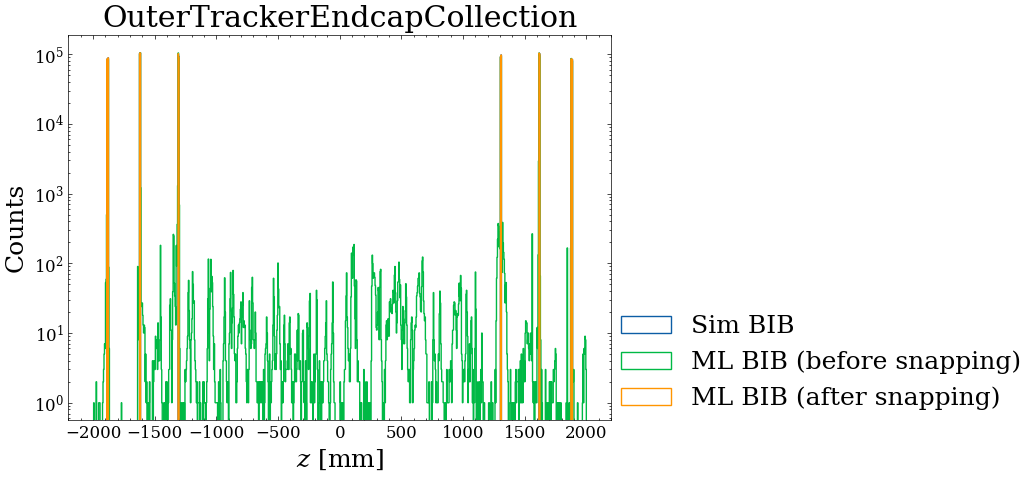

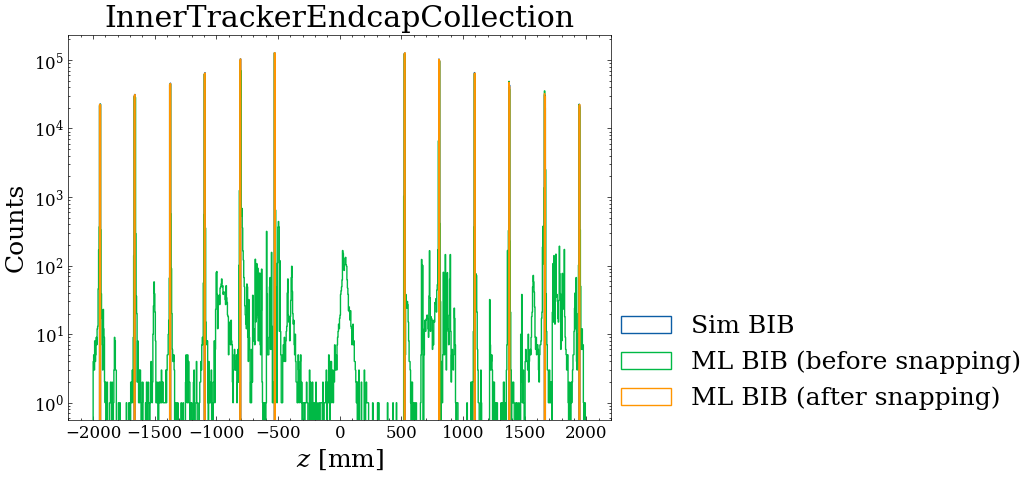

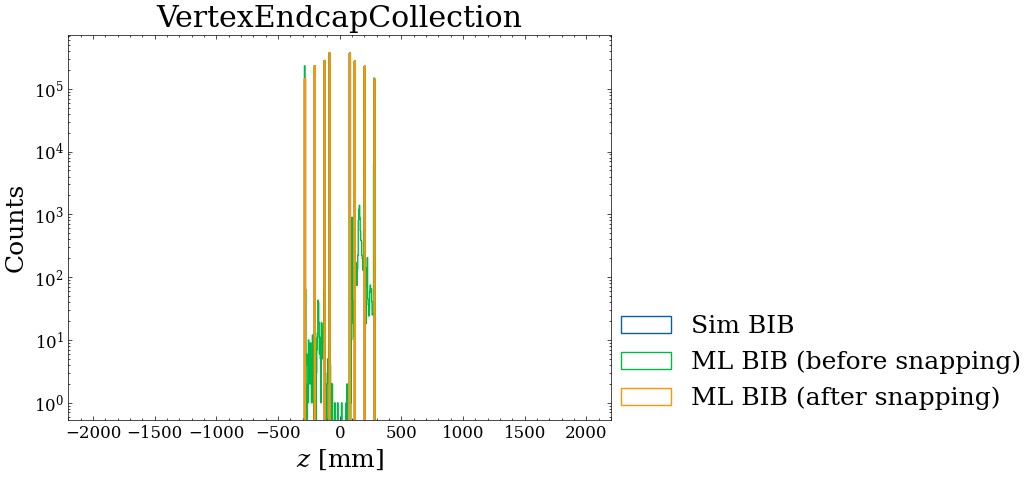

In [5]:



for col_name in collections:

    if "Endcap" in col_name:
        plt.figure()
    
        z_idx = feature_indices_dict[col_name]["z"]
        side_idx = feature_indices_dict[col_name]["side"]
        layer_idx = feature_indices_dict[col_name]["layer"]
        #sensor_idx = feature_indices_dict[col_name]["sensor"]
    
        # original samples
        z_samples = all_samples_dir[col_name][:, z_idx]
        sides = all_samples_dir[col_name][:, side_idx]
        layers = all_samples_dir[col_name][:, layer_idx]
        #sensors = all_samples_dir[col_name][:, sensor_idx]
    
    
        
        # z_lookup = build_z_lookup(
        #     all_data_dir[col_name],
        #     feature_indices_dict[col_name]["side"],
        #     feature_indices_dict[col_name]["layer"],
        #     feature_indices_dict[col_name]["sensor"],
        #     feature_indices_dict[col_name]["z"],
        # )
        z_lookup = build_xy_z_lookup(
            all_data_dir[col_name],
            feature_indices_dict[col_name]["side"],
            feature_indices_dict[col_name]["layer"],
            feature_indices_dict[col_name]["r"],
            feature_indices_dict[col_name]["phi"],
            feature_indices_dict[col_name]["z"],
        )


        plt.hist(
            all_data_dir[col_name][:, z_idx],
            bins=np.linspace(-2000, 2000, 1000),
            histtype="step",
            label="Sim BIB"
        )

        plt.hist(
            all_samples_dir[col_name][:,feature_indices_dict[col_name]["z"]],
            bins=np.linspace(-2000, 2000, 1000),
            histtype="step",
            label="ML BIB (before snapping)"
        )

            
        # # snap z to detector geometry
        # z_samples_snapped = snap_z_to_detector(
        #     z_samples, sides, layers, sensors, z_lookup
        #   #  z_samples, sides, layers, z_lookup
        
        # )
        z_samples_snapped =  snap_z_to_detector_xy(
            all_samples_dir[col_name][:, feature_indices_dict[col_name]["r"]],
            all_samples_dir[col_name][:, feature_indices_dict[col_name]["phi"]],
            sides,
            layers,
            z_lookup,
        )

        all_samples_dir[col_name][:,feature_indices_dict[col_name]["z"]] = z_samples_snapped
    
        # plot truth vs snapped samples
        
    
        plt.hist(
            z_samples_snapped,
            bins=np.linspace(-2000, 2000, 1000),
            histtype="step",
            label="ML BIB (after snapping)"
        )

        
        plt.title(col_name)
        plt.yscale("log")
        plt.legend()
        plt.xlabel("$z$ [mm]")
        plt.ylabel("Counts")
        plt.legend(loc = (1,0))
        plt.show()

In [6]:
# for col_name in collections:
#     print(col_name)
#     print(all_data_dir[col_name].shape, all_samples_dir[col_name].shape)

#     fig, ax = plt.subplots(1, 7, figsize = (20, 5))
#     for i in range(7):
#         ax[i].hist(all_data_dir[col_name][:,i], histtype = "step", bins = 100)
#         ax[i].hist(all_samples_dir[col_name][:,i], histtype = "step", bins = 100)
#         ax[i].set_xlabel(f"feature {i}")
#     ax[-1].legend()
#     plt.show()

Now we actually assign the cell IDs to the ML BIB by sending them through the lookup tree.

In [7]:



def get_col_hits_per_layer(data):

    

    col_hits_per_layer = {col: {} for col in collections}
    dists  = {col: {} for col in collections}
    cell_ids = {col: {} for col in collections}
    valid_masks = {col: {} for col in collections}

    
    
    for col_name in collections:
    
    
        # -----------------------------
        # 1. Extract coordinates
        # -----------------------------
        r = data[col_name][:,feature_indices_dict[col_name]["r"]]
        phi = data[col_name][:,feature_indices_dict[col_name]["phi"]]
        z = data[col_name][:,feature_indices_dict[col_name]["z"]]
        x = r*np.cos(phi)
        y = r*np.sin(phi)
        
        points = np.stack([x,y,z], axis=1)   # shape (N, 3)
    
        # -----------------------------
        # 2. Mask out NaNs / infs
        # -----------------------------
        valid_mask = np.isfinite(points).all(axis=1)
        points_valid = points[valid_mask]
        valid_masks[col_name] = valid_mask
    
        # Skip if nothing valid
        if len(points_valid) == 0:
            continue
    
        # -----------------------------
        # 3. Batch KDTree query
        # -----------------------------
        dists_batch, idx_batch = tree_map[col_name].query(points_valid)
    
        # -----------------------------
        # 4. Remove invalid KDTree hits
        # -----------------------------
        valid_idx_mask = idx_batch < len(cellid_layer_map[col_name])
    
        idx_batch = idx_batch[valid_idx_mask]
        dists[col_name]  = dists_batch[valid_idx_mask]
    
        # -----------------------------
        # 5. Map to (cell_id, layer)
        # -----------------------------
        cell_layer = cellid_layer_map[col_name][idx_batch]
        layers = cell_layer[:, 1]
        cell_ids[col_name] = cell_layer[:, 0]
    
        # -----------------------------
        # 6. Count hits per layer (vectorized)
        # -----------------------------
        unique_layers, counts = np.unique(layers, return_counts=True)
    
        for layer, count in zip(unique_layers, counts):
            col_hits_per_layer[col_name][layer] = (
                col_hits_per_layer[col_name].get(layer, 0) + count
            )


    return col_hits_per_layer, dists, cell_ids, valid_masks

First apply masks to the collections, then assign cell ids

In [8]:
col_hits_per_layer_truth, dists_truth, cell_ids_truth, valid_mask = get_col_hits_per_layer(all_data_dir)


flow_samples_masked, flow_samples_masked_stratified = build_masked_datasets(all_data_dir, all_samples_dir, collections, NUM_COND_INPUTS, feature_indices_dict, stratify=False)
col_hits_per_layer_samples, dists_samples, cell_ids_samples, valid_masks = get_col_hits_per_layer(flow_samples_masked)


OuterTrackerBarrelCollection: 47.064295855917585% of samples pass (1544028 after masking, 3280678 before masking)
OuterTrackerEndcapCollection: 99.86512714682858% of samples pass (1463848 after masking, 1465825 before masking)
InnerTrackerBarrelCollection: 68.20372696625437% of samples pass (2677812 after masking, 3926196 before masking)
InnerTrackerEndcapCollection: 99.62487900071778% of samples pass (1608622 after masking, 1614679 before masking)
VertexBarrelCollection: 78.64506572056852% of samples pass (1674484 after masking, 2129166 before masking)
VertexEndcapCollection: 99.28199862756571% of samples pass (4066959 after masking, 4096371 before masking)


Diagnostic plot

OuterTrackerBarrelCollection 3280678
OuterTrackerBarrelCollection 1544028
OuterTrackerEndcapCollection 1465825
OuterTrackerEndcapCollection 1463848
InnerTrackerBarrelCollection 3926196
InnerTrackerBarrelCollection 2677812
InnerTrackerEndcapCollection 1614679
InnerTrackerEndcapCollection 1608622
VertexBarrelCollection 2129166
VertexBarrelCollection 1674484
VertexEndcapCollection 4096371
VertexEndcapCollection 4066959


/tmp/ipykernel_1172897/289827073.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


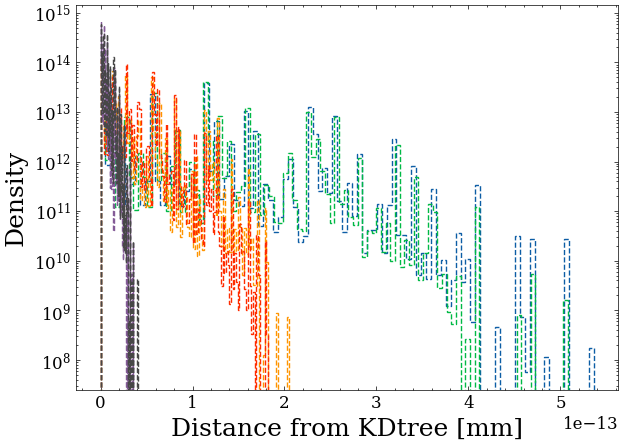

OuterTrackerBarrelCollection 28.789762879947773
OuterTrackerEndcapCollection 16.02522939540171
InnerTrackerBarrelCollection 90.08272425398049
InnerTrackerEndcapCollection 56.59589387687101
VertexBarrelCollection 99.99844728286445
VertexEndcapCollection 99.99879516857682


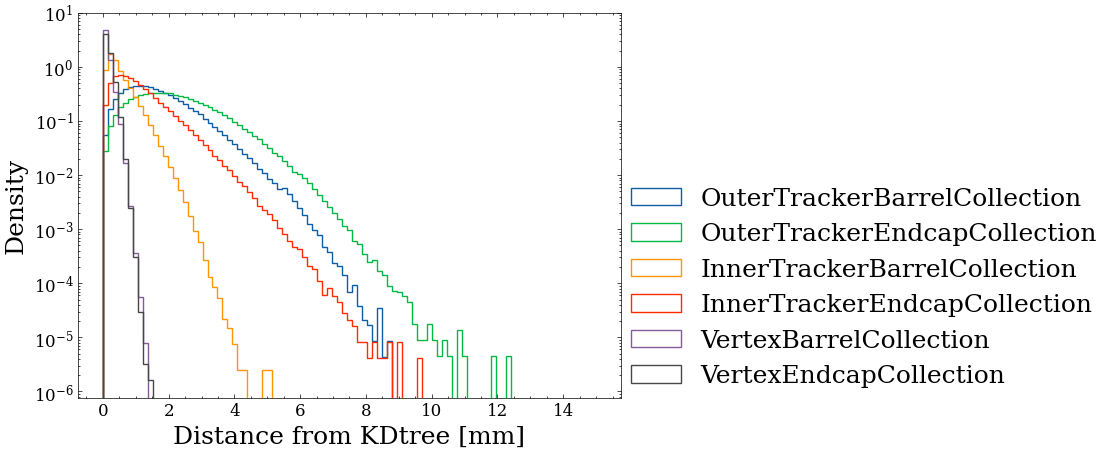

In [15]:
for key in all_data_dir.keys():
    print(key, len(all_data_dir[key]))
    print(key, len(flow_samples_masked[key]))


plt.figure()
for i, col in enumerate(collections):
    plt.hist(dists_truth[col], bins = 100, histtype = "step", density = True, linestyle = "dashed", color = f"C{i}")
plt.yscale("log")
plt.xlabel("Distance from KDtree [mm]")
plt.ylabel("Density")
plt.legend()
plt.show()

plt.figure()
for i, col in enumerate(collections):
    plt.hist(dists_samples[col], bins = np.linspace(0, 15, 100), histtype = "step", density = True, color = f"C{i}", label = col)
    num_pass = dists_samples[col] < 1
    print(col,100*sum(num_pass)/len(num_pass))
plt.yscale("log")
plt.xlabel("Distance from KDtree [mm]")
plt.ylabel("Density")
plt.legend(loc = (1,0))
plt.show()

More sanity checks (not important)

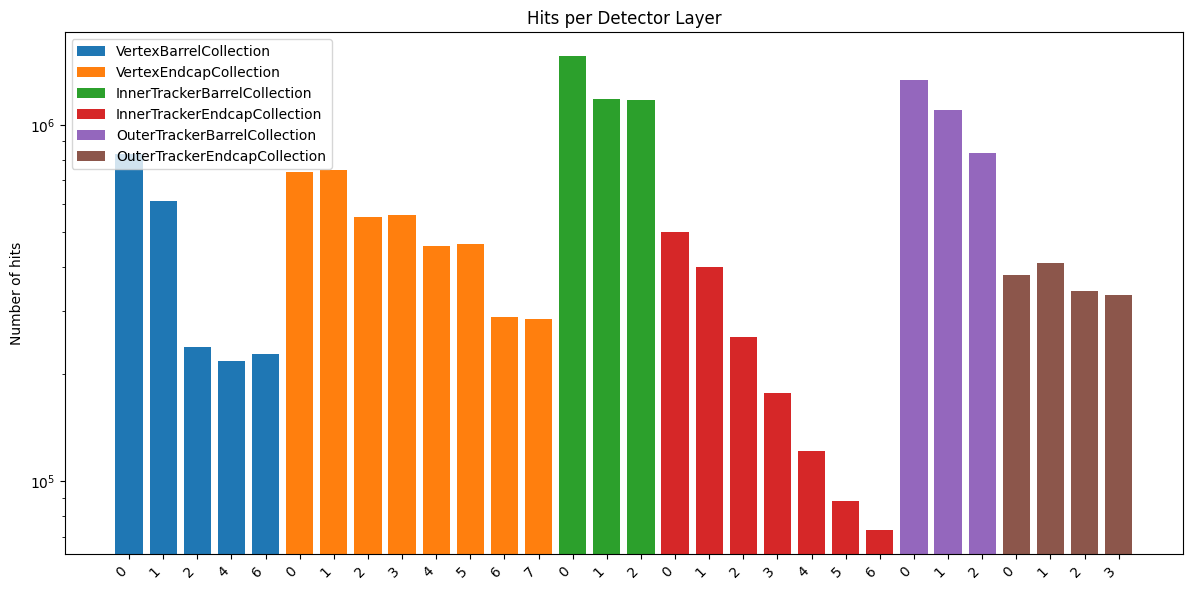

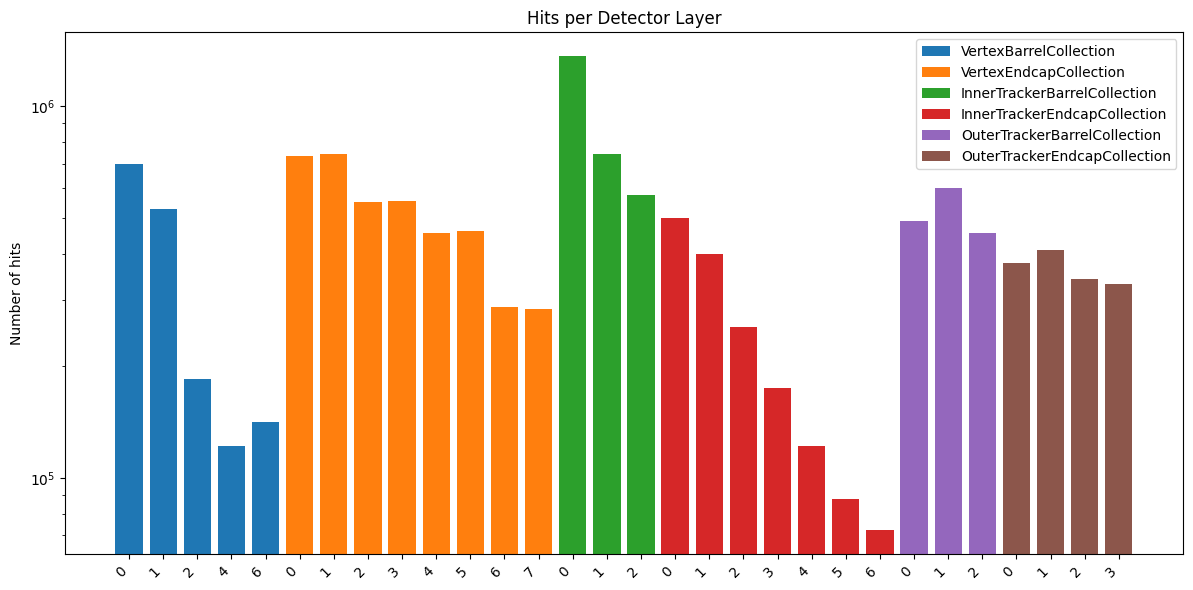

In [12]:
collections_order = [
    'VertexBarrelCollection',
    'VertexEndcapCollection',
    'InnerTrackerBarrelCollection',
    'InnerTrackerEndcapCollection',
    'OuterTrackerBarrelCollection',
    'OuterTrackerEndcapCollection'
]


def make_plot(col_hits_per_layer):
    
    # Prepare x positions
    width = 0.1  # width of each bar
    x_offsets = np.arange(0, len(col_hits_per_layer[collections_order[0]]))  # base positions for first collection
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Keep track of total x positions
    x_pos = 0
    x_labels = []
    x_ticks = []
    
    for coll in collections_order:
        layers = sorted(col_hits_per_layer[coll].keys())  # sort layers numerically
        counts = [col_hits_per_layer[coll][l] for l in layers]
    
        # compute positions for this collection
        positions = x_pos + np.arange(len(layers))
        ax.bar(positions, counts, width=0.8, label=coll)
        
        # collect labels and ticks
        x_labels.extend([f"{l}" for l in layers])
        x_ticks.extend(positions)
        
        # update x_pos for next collection to avoid overlap
        x_pos = positions[-1] + 1  # add gap between collections
    
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.set_ylabel("Number of hits")
    ax.set_title("Hits per Detector Layer")
    ax.legend()
    plt.tight_layout()
    plt.yscale("log")
    plt.savefig("figures/hits_per_detector_layer.png")
    plt.show()


make_plot(col_hits_per_layer_truth)
make_plot(col_hits_per_layer_samples)

Randomly save out 10% of the ML BIB samples so that digitization and reconstruction run faster

In [13]:


for col in collections_order:

    print(col)
    #print(flow_samples_masked[col].shape)
    #print(cell_ids_samples[col].shape)


    loc = np.concatenate([flow_samples_masked[col], cell_ids_samples[col].reshape(-1,1)], axis = 1)

    
    print(loc.shape)

    n_samples = int(0.1 * len(loc))

    idx = np.random.choice(len(loc), size=n_samples, replace=False)

    loc_subset = loc[idx]

    print(loc_subset.shape)



    np.save(f"/pscratch/sd/r/rmastand/muon_collider/npys/flow_samples/{col}.npy", loc_subset)
    #print(loc.shape,)

VertexBarrelCollection
(1674484, 8)
(167448, 8)
VertexEndcapCollection
(4066959, 8)
(406695, 8)
InnerTrackerBarrelCollection
(2677812, 8)
(267781, 8)
InnerTrackerEndcapCollection
(1608622, 8)
(160862, 8)
OuterTrackerBarrelCollection
(1544028, 8)
(154402, 8)
OuterTrackerEndcapCollection
(1463848, 8)
(146384, 8)


In [ ]:
data = []

collections_order = [
    'VertexBarrelCollection',
    'VertexEndcapCollection',
    'InnerTrackerBarrelCollection',
    'InnerTrackerEndcapCollection',
    'OuterTrackerBarrelCollection',
    'OuterTrackerEndcapCollection'
]


for col in collections_order:
    tmp = np.load(f"/pscratch/sd/r/rmastand/muon_collider/npys/flow_samples/{col}.npy")
    data.append(tmp)

    plt.figure()
    plt.hist(tmp[:,3], bins = 200)
    plt.title(col)
    plt.show()

data = np.concatenate(data)
print(data.shape)


In [ ]:
for i in range(data.shape[1]):
    plt.figure()
    plt.hist(data[:,i], bins = 100)
    plt.show()